# LP・診断アプリ ファネル分析

**分析ゴール**:集客〜LP〜診断アプリ〜申込みという導線のどこが機能し、どこで離脱しているかを明らかにする

**分析項目**(analysis-design.md 準拠)
1. チャネル別の流入数・CVR・CPA比較
2. ファネル各ステップの通過率・離脱率
3. 診断アプリ利用有無によるCVRの比較
4. 診断結果タイプ別のCTAクリック率・CVR比較
5. チャネル×診断利用有無のクロス分析


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

plt.rcParams["figure.dpi"] = 110
COLOR_MAIN = "#8fae94"
COLOR_ACCENT = "#e2a37b"
COLOR_MUTED = "#B0B7C3"

df = pd.read_csv("session_data.csv")
ad_cost = pd.read_csv("channel_ad_cost.csv")

print("セッション数:", len(df))
df.head()

セッション数: 2000


,session_id,channel,visit_date,reached_pain_section,diagnostic_started,diagnostic_completed,diagnostic_result_type,cta_click,conversion
0,S00001,検索広告,2026-08-19,0,0,0,NaN,0,0
1,S00002,自然検索,2026-08-03,1,1,1,rest,0,0
2,S00003,自然検索,2026-07-07,1,0,0,NaN,0,0
3,S00004,SNS広告,2026-07-20,1,0,0,NaN,1,1
4,S00005,SNS広告,2026-07-30,1,1,1,reset,0,0


## A-1. チャネル別の流入数・CVR・CPA

In [2]:
channel_summary = df.groupby("channel").agg(
    sessions=("session_id", "count"),
    conversions=("conversion", "sum"),
).reset_index()
channel_summary["CVR(%)"] = (channel_summary["conversions"] / channel_summary["sessions"] * 100).round(2)
channel_summary = channel_summary.merge(ad_cost, on="channel", how="left")
channel_summary["CPA(円)"] = channel_summary.apply(
    lambda r: round(r["monthly_ad_cost_jpy"] / r["conversions"]) if r["conversions"] > 0 and r["monthly_ad_cost_jpy"] > 0 else None,
    axis=1,
)
channel_summary = channel_summary.sort_values("sessions", ascending=False)
channel_summary

,channel,sessions,conversions,CVR(%),monthly_ad_cost_jpy,CPA(円)
0,SNS広告,1113,145,13.03,450000,3103.0
1,検索広告,378,24,6.35,380000,15833.0
3,自然検索,375,44,11.73,0,NaN
2,紹介,134,20,14.93,0,NaN


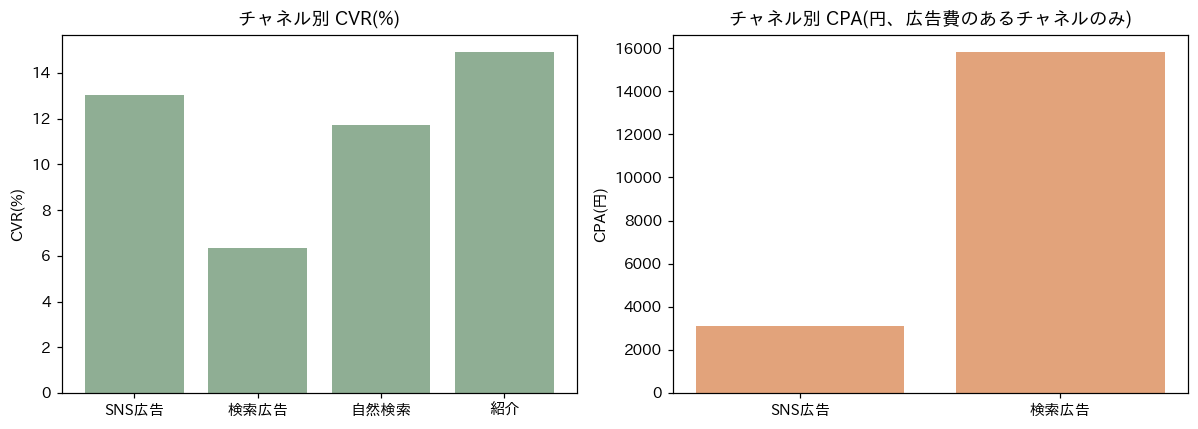

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

order = channel_summary["channel"]
axes[0].bar(order, channel_summary["CVR(%)"], color=COLOR_MAIN)
axes[0].set_title("チャネル別 CVR(%)")
axes[0].set_ylabel("CVR(%)")

cpa_data = channel_summary.dropna(subset=["CPA(円)"])
axes[1].bar(cpa_data["channel"], cpa_data["CPA(円)"], color=COLOR_ACCENT)
axes[1].set_title("チャネル別 CPA(円、広告費のあるチャネルのみ)")
axes[1].set_ylabel("CPA(円)")

plt.tight_layout()
plt.savefig("fig_channel_cvr_cpa.png")
plt.show()

**読み取り**:SNS広告はセッション数・CVRともに良好でCPAも低い。検索広告はCVRが低くCPAが高く、
費用対効果が他チャネルに劣る。紹介はセッション数こそ少ないがCVRは最も高い(広告費もかからない)。


## A-2. ファネル各ステップの通過率・離脱率

In [4]:
funnel_steps = {
    "① LP訪問": len(df),
    "② 悩みセクション到達": df["reached_pain_section"].sum(),
    "③ 診断アプリ開始": df["diagnostic_started"].sum(),
    "④ 診断アプリ完了": df["diagnostic_completed"].sum(),
    "⑤ CTAクリック": df["cta_click"].sum(),
    "⑥ 申込み完了(CV)": df["conversion"].sum(),
}

funnel_df = pd.DataFrame(list(funnel_steps.items()), columns=["ステップ", "人数"])
funnel_df["前ステップ比(%)"] = (funnel_df["人数"] / funnel_df["人数"].shift(1) * 100).round(1)
funnel_df["全体比(%)"] = (funnel_df["人数"] / funnel_df["人数"].iloc[0] * 100).round(1)
funnel_df

,ステップ,人数,前ステップ比(%),全体比(%)
0,① LP訪問,2000,NaN,100.0
1,② 悩みセクション到達,1275,63.7,63.7
2,③ 診断アプリ開始,461,36.2,23.0
3,④ 診断アプリ完了,328,71.1,16.4
4,⑤ CTAクリック,375,114.3,18.8
5,⑥ 申込み完了(CV),233,62.1,11.6


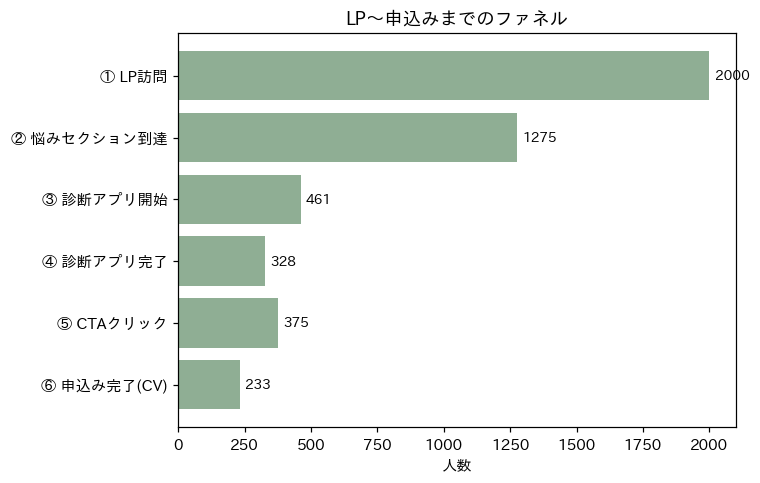

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = [COLOR_MAIN] * len(funnel_df)
ax.barh(funnel_df["ステップ"][::-1], funnel_df["人数"][::-1], color=colors[::-1])
ax.set_xlabel("人数")
ax.set_title("LP〜申込みまでのファネル")
for i, v in enumerate(funnel_df["人数"][::-1]):
    ax.text(v + 20, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("fig_funnel.png")
plt.show()

**読み取り**(実行結果に基づく):

- **②→③(悩みセクション到達 → 診断アプリ開始)の離脱が最も大きい**:悩みセクションまで読んだ1,275人のうち、
  診断を開始したのは461人(36.2%)にとどまる。ここが最大のボトルネック。
- **③→④(診断開始 → 完了)の離脱は相対的に小さい**:開始した461人のうち328人(71.1%)が完了しており、
  「診断の中身(質問の多さ・分かりやすさ)」より「診断への入り口」の方に改善余地が大きいと考えられる。
- **⑤CTAクリック(375人)が④診断完了(328人)より多い点に注意**:これは診断を経由せず、
  悩みセクションから直接LPのCTAをクリックした人も⑤に合流しているためで、
  ④→⑤は単純な直線的ファネルとしては読めない(診断経由ルートと直接ルートの合流点)。
  診断経由でCTAに至った人数だけを見たい場合は、A-4の「診断結果タイプ別」の人数を参照する。


## A-3. 診断アプリ利用有無によるCVR比較

In [6]:
diag_cvr = df.groupby("diagnostic_completed")["conversion"].mean().mul(100).round(2)
diag_cvr.index = ["診断未完了(未実施含む)", "診断完了"]
diag_cvr_df = diag_cvr.reset_index()
diag_cvr_df.columns = ["区分", "CVR(%)"]
diag_cvr_df

,区分,CVR(%)
0,診断未完了(未実施含む),6.88
1,診断完了,35.98


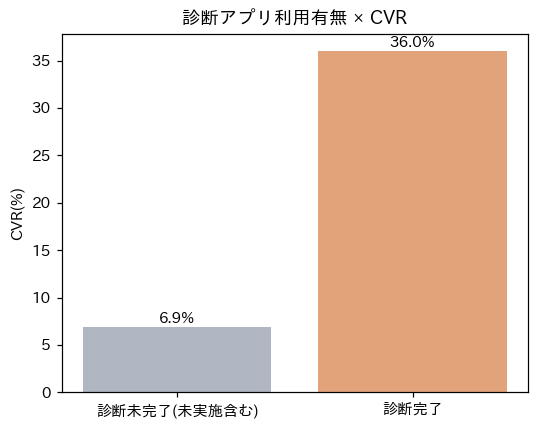

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(diag_cvr_df["区分"], diag_cvr_df["CVR(%)"], color=[COLOR_MUTED, COLOR_ACCENT])
ax.set_ylabel("CVR(%)")
ax.set_title("診断アプリ利用有無 × CVR")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5, f"{b.get_height():.1f}%", ha="center")
plt.tight_layout()
plt.savefig("fig_diagnostic_effect.png")
plt.show()

## A-4. 診断結果タイプ別 CTAクリック率・CVR

In [8]:
diag_completed = df[df["diagnostic_completed"] == 1]
type_summary = diag_completed.groupby("diagnostic_result_type").agg(
    人数=("session_id", "count"),
    CTAクリック率=("cta_click", "mean"),
    CVR=("conversion", "mean"),
).round(4)
type_summary["CTAクリック率(%)"] = (type_summary["CTAクリック率"] * 100).round(1)
type_summary["CVR(%)"] = (type_summary["CVR"] * 100).round(1)
type_summary = type_summary[["人数", "CTAクリック率(%)", "CVR(%)"]]
type_summary

,人数,CTAクリック率(%),CVR(%)
diagnostic_result_type,,,
overwork,97,42.3,32.0
reset,108,49.1,32.4
rest,123,60.2,42.3


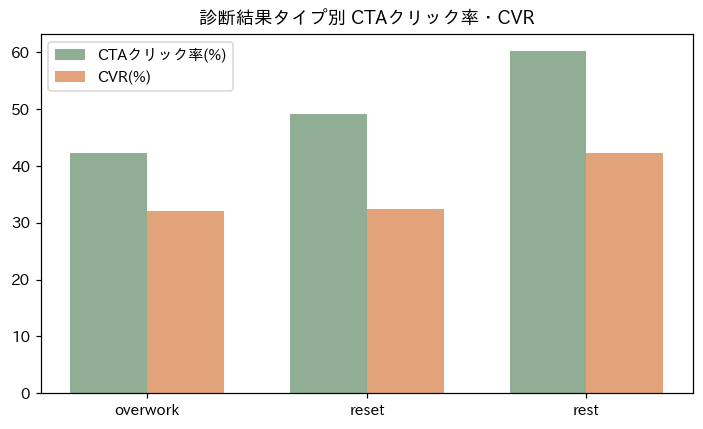

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4))
x = range(len(type_summary))
w = 0.35
ax.bar([i - w/2 for i in x], type_summary["CTAクリック率(%)"], width=w, label="CTAクリック率(%)", color=COLOR_MAIN)
ax.bar([i + w/2 for i in x], type_summary["CVR(%)"], width=w, label="CVR(%)", color=COLOR_ACCENT)
ax.set_xticks(list(x))
ax.set_xticklabels(type_summary.index)
ax.set_title("診断結果タイプ別 CTAクリック率・CVR")
ax.legend()
plt.tight_layout()
plt.savefig("fig_type_cvr.png")
plt.show()

## A-5. チャネル × 診断利用有無 のクロス分析

In [10]:
cross = df.groupby(["channel", "diagnostic_completed"])["conversion"].agg(["count", "mean"]).reset_index()
cross["CVR(%)"] = (cross["mean"] * 100).round(1)
cross["diagnostic_completed"] = cross["diagnostic_completed"].map({0: "診断未完了", 1: "診断完了"})
pivot = cross.pivot(index="channel", columns="diagnostic_completed", values="CVR(%)")
pivot

diagnostic_completed,診断完了,診断未完了
channel,,
SNS広告,38.9,7.7
検索広告,23.5,4.7
紹介,27.3,10.9
自然検索,38.0,5.6


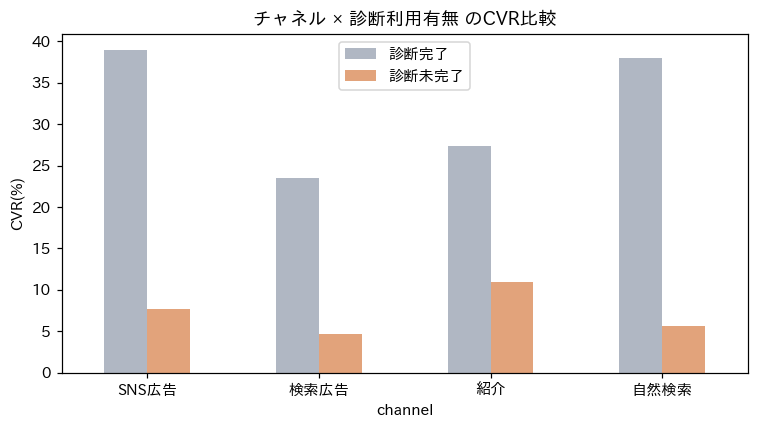

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
pivot.plot(kind="bar", ax=ax, color=[COLOR_MUTED, COLOR_ACCENT])
ax.set_ylabel("CVR(%)")
ax.set_title("チャネル × 診断利用有無 のCVR比較")
ax.legend(title="")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("fig_channel_diagnostic_cross.png")
plt.show()

## まとめ・改善提案

実行結果の数値に基づき、以下の4点をまとめる。

### 1. 予算配分の見直し余地あり
SNS広告(CPA 3,103円)と比較して、検索広告はCPAが15,833円と約5倍に達しており、
CVRも6.35%とSNS広告(13.03%)の半分以下だった。**検索広告の予算をSNS広告へ再配分する**、
または検索広告のクリエイティブ・ターゲティングを見直すことが優先課題となる。

### 2. ファネル上の最大のボトルネックは「診断アプリへの入り口」
悩みセクション到達者(1,275人)のうち、診断を開始したのは36.2%(461人)にとどまる一方、
開始後の完了率は71.1%と高い。**診断アプリ自体の完成度は問題ではなく、
「診断への誘導カードへの気づきやすさ・魅力づけ」を改善する余地が最も大きい。**

### 3. 診断アプリはCVR改善に明確に貢献している
診断を完了したセッションのCVRは35.98%、完了しなかったセッションは6.88%であり、
**診断完了者は非完了者の約5.2倍のCVR**だった。診断アプリへの投資(今回の企画・実装)は
効果があったと言える。→ だからこそ「2」の入り口改善に投資する価値が高い。

### 4. 診断結果タイプ別では「休息不足タイプ(rest)」が最も転換しやすい
CTAクリック率・CVRともに rest(60.2% / 42.3%)が最も高く、
overwork(42.3% / 32.0%)・reset(49.1% / 32.4%)を上回った。
**reset・overworkタイプの結果画面の訴求文言やCTA周りの表現を、
restタイプに近づける形で改善する余地がある。**

### 5. チャネル×診断のクロスでも、診断完了は全チャネルでCVRを押し上げている
SNS広告・自然検索では診断完了時のCVRが特に高く(ともに38%台)、
検索広告・紹介経由でも診断完了によるCVR向上が確認できた。
**チャネルを問わず、診断アプリへの誘導を強化する施策(2)の効果が期待できる。**
